In [21]:
import os
import logging, timeit
#from btEngine2.DataLoader import DataLoader
from btEngine2.MarketData import MarketData
from btEngine2.TradingRule import TradingRule
from btEngine2.Indicators import *


import matplotlib.pyplot as plt


import platform
import pandas as pd

pd.options.display.float_format = lambda x: f'{x:,.0f}' if abs(x) >= 1000 else (f'{x:.2f}' if abs(x) < 10 else f'{x:.1f}')
pd.set_option('future.no_silent_downcasting', True)

pd.set_option('display.max_rows', 40)


# Detect operating system
if platform.system() == "Windows":
    ticker_csv_path = r'G:\Projects\BackTesting1.0\Data\Inputs\TickerList-Futs.csv'
    save_directory = r"G:\Projects\BackTesting1.0\Data\Bloomberg\Futures"
    helper_directory = r'G:\Projects\BackTesting1.0\Data\Bloomberg\HelperFiles'
    bt_folder = r'BackTests\mr_short_resrch'
    av_folder = r'G:\Projects\BackTesting1.0\Data\Inputs\AssetSizing-Futs.csv'
else:  # Assume macOS for other cases
    ticker_csv_path = r'Data/Inputs/TickerList-Futs.csv'
    save_directory = r"Data/Bloomberg/Futures"
    helper_directory = r'Data/Bloomberg/HelperFiles'
    bt_folder = r'BackTests/mr_short_resrch'
    av_folder = r'Data/Inputs/AssetSizing-Futs.csv'



# Define paths to auxiliary data for MarketData
tick_values_path = os.path.join(helper_directory, 'fut_val_pt.parquet')
fx_rates_path = os.path.join(helper_directory, 'fxHist.parquet')

# Initialize the MarketData
market_data = MarketData(
    base_directory=save_directory,
    tick_values_path=tick_values_path,
    fx_rates_path=fx_rates_path,
    instrument_type="Futures",
    n_threads=8,  # Number of threads for parallel data loading
    log_level=logging.ERROR  # Set to DEBUG for more detailed logs
)


pSizeParamsUse = {
    'AssetVol': 1000000,  # Target asset volatility in USD
    'VolLookBack': 30,
    'VolMethod': 'ewm'  # Lookback period for volatility calculation
}

In [22]:
tick = 'CA1 Index'
# Access data for a specific ticker
try:
    test_df = market_data.get_ticker_data(tick)
    print(test_df)
except ValueError as e:
    print(e)

# Access all preprocessed data
all_data = market_data.get_data()
print(f"Total tickers loaded: {len(all_data)}")

# Access FX rates
fx_rates = market_data.get_fx_rates()
# Access tick values
tick_values = market_data.get_tick_values()
# Access asset classes
asset_classes = market_data.get_asset_classes()

#market_data = market_data.date_filter(start_date='01012010')
test_df.to_pandas().to_clipboard()

shape: (6_055, 14)
┌────────────┬────────┬────────┬────────┬───┬─────────┬─────────┬─────────────────┬────────────────┐
│ Date       ┆ Open   ┆ High   ┆ Low    ┆ … ┆ BadOHLC ┆ FX_Rate ┆ Tick_Value_Base ┆ Tick_Value_USD │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆   ┆ ---     ┆ ---     ┆ ---             ┆ ---            │
│ date       ┆ f64    ┆ f64    ┆ f64    ┆   ┆ bool    ┆ f64     ┆ f64             ┆ f64            │
╞════════════╪════════╪════════╪════════╪═══╪═════════╪═════════╪═════════════════╪════════════════╡
│ 2001-03-19 ┆ null   ┆ null   ┆ null   ┆ … ┆ false   ┆ 0.8999  ┆ 50.0            ┆ 44.995         │
│ 2001-03-20 ┆ 234.85 ┆ 234.85 ┆ 231.85 ┆ … ┆ false   ┆ 0.9094  ┆ 50.0            ┆ 45.47          │
│ 2001-03-21 ┆ 220.65 ┆ 223.85 ┆ 220.65 ┆ … ┆ false   ┆ 0.8965  ┆ 50.0            ┆ 44.825         │
│ 2001-03-22 ┆ 220.65 ┆ 223.85 ┆ 220.65 ┆ … ┆ false   ┆ 0.8892  ┆ 50.0            ┆ 44.46          │
│ 2001-03-23 ┆ 213.85 ┆ 215.85 ┆ 213.85 ┆ … ┆ false   ┆ 0.8899  ┆ 50.0  

In [91]:
import pandas as pd
import numpy as np
import polars as pl

def compute_rsi(close_prices: pd.Series, period: int = 14) -> pd.Series:
    """
    Compute the Relative Strength Index (RSI) efficiently.

    :param close_prices: Pandas Series of closing prices.
    :param period: Lookback period for RSI calculation (default: 14).
    :return: Pandas Series of RSI values.
    """

    # Compute price differences
    delta = close_prices.diff()

    # Separate gains and losses
    gains = np.where(delta > 0, delta, 0)
    losses = np.where(delta < 0, -delta, 0)  # Make losses positive for averaging

    # Compute exponential moving averages (EWM) for gains and losses
    avg_gain = pd.Series(gains).ewm(span=period, adjust=False).mean()
    avg_loss = pd.Series(losses).ewm(span=period, adjust=False).mean()

    # Compute Relative Strength (RS)
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    # Return RSI as a Pandas Series with the same index
    return pd.Series(rsi, index=close_prices.index)


def short_ibstrat(
    df: pl.DataFrame,
    ma_period: int = 200,
    roc_threshold: float = 0.02,
    ibs_threshold: float = 0.2,
    roc_period: int = 2,
    rsi_period: int = 3,
    rsi_threshold: float = 85,
    max_hold_days: int = 2
) -> pl.DataFrame:
    """
    Short trading strategy based on moving average, rate of change, RSI, and IBS.

    :param df: Polars DataFrame containing asset data.
    :param ma_period: Lookback period for moving average (default: 200).
    :param roc_threshold: Rate of change threshold for entry (default: 2%).
    :param ibs_threshold: Exit threshold for IBS (default: 0.2).
    :param rsi_period: RSI lookback period for additional entry condition (default: 3).
    :param rsi_threshold: RSI threshold for entry (default: 80).
    :param max_hold_days: Maximum number of days to hold a trade (default: 2).
    :return: Polars DataFrame with trading signals appended.
    """

    # Convert to Pandas for easier calculations
    df = df.to_pandas()

    # Ensure the dataframe is sorted
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)

    # Calculate the 200-day simple moving average (SMA)
    df['MA_200'] = df['Close'].rolling(window=ma_period).mean()

    # Calculate the 2-day rate of change (ROC)
    df['ROC'] = (df['Close'] / df['Close'].shift(roc_period) - 1)

    # Calculate the 3-day RSI
    df['RSI_3'] = compute_rsi(df['Close'], period=rsi_period)

    # IBS Calculation: (Close - Low) / (High - Low)
    df['IBS'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

    # Initialize the trading rule columns
    df['Signal'] = 0
    df['TradeEntry'] = np.nan
    df['TradeExit'] = np.nan
    df['InTrade'] = 0

    # Track the state of the position
    in_trade = False
    trade_start_index = None

    for i in range(ma_period, len(df) - 1):  # Start at ma_period to avoid lookback issues
        if not in_trade:
            # Entry Conditions for Short
            if (df['Close'].iloc[i] < df['MA_200'].iloc[i] and  # Below 200-day MA
                df['ROC'].iloc[i] >= roc_threshold and  
                df['Close'].iloc[i] > df['High'].iloc[i - 1] and  # Close > Previous High
                df['RSI_3'].iloc[i] > rsi_threshold):  # RSI(3) > 80

                df.loc[df.index[i + 1], 'Signal'] = -1  # Short signal on next open
                df.loc[df.index[i + 1], 'TradeEntry'] = df.loc[df.index[i + 1], 'Open']  # Entry at next open

                in_trade = True
                trade_start_index = i + 1
                df.loc[df.index[trade_start_index], 'InTrade'] = -1
                hold_days = 0  # Track the number of days in trade

        elif in_trade:
            hold_days += 1  # Increment the hold duration

            # Exit Condition: IBS < 0.2 or held for max_hold_days
            if df['IBS'].iloc[i] < ibs_threshold or hold_days >= max_hold_days:
                df.loc[df.index[i], 'Signal'] = 1  # Exit signal
                df.loc[df.index[i], 'TradeExit'] = df.loc[df.index[i], 'Close']  # Exit at Close
                df.loc[df.index[i], 'InTrade'] = -1

                in_trade = False  # Close the position
                trade_start_index = None
                hold_days = 0  # Reset hold duration

            else:
                # Mark that we are in a trade
                df.loc[df.index[i], 'InTrade'] = -1

    # Convert back to Polars
    df = pl.DataFrame(df)

    return df

In [92]:
market_data.get_asset_classes()

{'crypto': ['BTC1 Curncy', 'DCR1 Curncy'],
 'eq-divf': ['DBE3 Index', 'DED3 Index', 'MND3 Index', 'ASD3 Index'],
 'eq-us': ['RTY1 Index', 'NQ1 Index', 'DM1 Index', 'ES1 Index'],
 'fx-dm': ['DX1 Curncy',
  'JY1 Curncy',
  'SDE1 Curncy',
  'NV1 Curncy',
  'AD1 Curncy',
  'EC1 Curncy',
  'SF1 Curncy',
  'BP1 Curncy',
  'NO1 Curncy',
  'CD1 Curncy',
  'SE1 Curncy'],
 'fi-us': ['TY1 Comdty',
  'WN1 Comdty',
  'CN1 Comdty',
  'US1 Comdty',
  'TU1 Comdty',
  'FV1 Comdty'],
 'comm-soft': ['RR1 Comdty',
  'BO1 Comdty',
  'KC1 Comdty',
  'CA1 Comdty',
  'QW1 Comdty',
  'S 1 Comdty',
  'QC1 Comdty',
  'RS1 Comdty',
  'C 1 Comdty',
  'W 1 Comdty',
  'FC1 Comdty',
  'SM1 Comdty',
  'SB1 Comdty',
  'YW1 Comdty'],
 'comm-base': ['LA1 Comdty',
  'LN1 Comdty',
  'SCO1 Comdty',
  'HG1 Comdty',
  'LP1 Comdty'],
 'stir': ['IR6 Comdty',
  'SFR8 Comdty',
  'SFI6 Comdty',
  'SSY4 Comdty',
  'ER6 Comdty'],
 'eq-em': ['XB1 Index',
  'KM1 Index',
  'XU1 Index',
  'HC1 Index',
  'ZVL1 Index',
  'QZ1 Index',
  'M

In [112]:
ibs_mr_short = TradingRule(
    market_data=market_data,
    trading_rule_function=short_ibstrat,
    trading_params={"ma_period": 200, "roc_threshold": 0.02, "ibs_threshold": 0.2},
    position_sizing_params=pSizeParamsUse,
    cont_rule=False,
    name_label='IBS_MR_Short',
    bt_folder=bt_folder
)

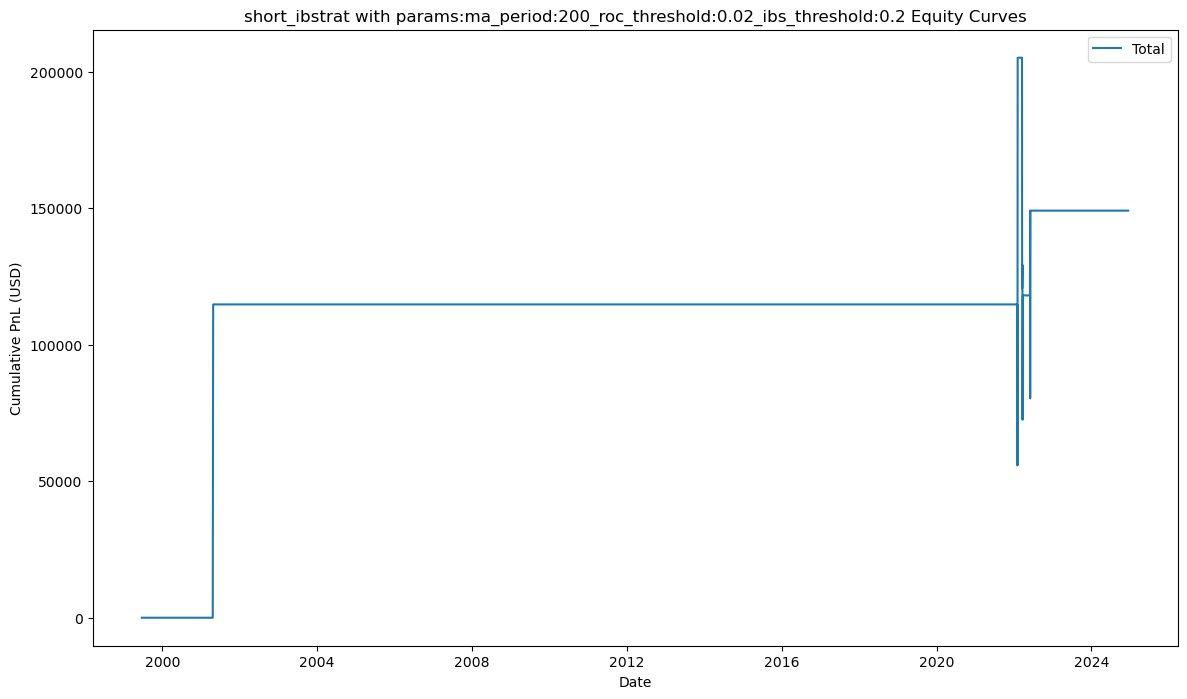

,Total
Date,
1999-06-21,0.00
1999-06-22,0.00
1999-06-23,0.00
1999-06-24,0.00
1999-06-25,0.00
...,...
2024-12-09,"149,110"
2024-12-10,"149,110"
2024-12-11,"149,110"


In [113]:
ibs_mr_short.plot_equity(filter_assets=['NQ1 Index'])

In [225]:
import pandas as pd
import numpy as np
import polars as pl

def compute_adx(df: pd.DataFrame, period: int = 15) -> pd.Series:
    """
    Compute the ADX (Average Directional Index) efficiently.

    :param df: Pandas DataFrame containing 'High', 'Low', and 'Close' prices.
    :param period: Lookback period for ADX calculation (default: 15).
    :return: Pandas Series of ADX values.
    """

    high, low, close = df['High'], df['Low'], df['Close']

    # Calculate true range components
    tr1 = high - low
    tr2 = np.abs(high - close.shift(1))
    tr3 = np.abs(low - close.shift(1))

    true_range = np.maximum(tr1, np.maximum(tr2, tr3))

    # Directional movements
    plus_dm = np.where((high - high.shift(1)) > (low.shift(1) - low), high - high.shift(1), 0)
    minus_dm = np.where((low.shift(1) - low) > (high - high.shift(1)), low.shift(1) - low, 0)

    # Smooth moving averages
    atr = pd.Series(true_range).ewm(span=period, adjust=False).mean()
    plus_di = 100 * pd.Series(plus_dm).ewm(span=period, adjust=False).mean() / atr
    minus_di = 100 * pd.Series(minus_dm).ewm(span=period, adjust=False).mean() / atr

    # Compute ADX
    dx = 100 * np.abs(plus_di - minus_di) / (plus_di + minus_di)
    adx = pd.Series(dx).ewm(span=period, adjust=False).mean()

    return adx


def tt_strat(
    df: pl.DataFrame,
    adx_period: int = 15,
    zscore_lookback: int = 21,
    zscore_threshold: float = -1.25,
    consecutive_lowers: int = 2,
    adx_threshold: float = 15,
    max_hold_days: int = 5
) -> pl.DataFrame:
    """
    Monday Reversal Strategy with stricter entry conditions.

    :param df: Polars DataFrame containing asset data.
    :param adx_period: Lookback period for ADX (default: 15).
    :param zscore_lookback: Lookback period for return z-score calculation (default: 21 days).
    :param zscore_threshold: Z-score threshold for Monday's return (default: -1.25).
    :param consecutive_lowers: Number of consecutive lower closes required for entry (default: 2).
    :param adx_threshold: Minimum ADX value for entry (default: 15).
    :param max_hold_days: Maximum number of days to hold a trade (default: 5).
    :return: Polars DataFrame with trading signals appended.
    """

    # Convert to Pandas for easier calculations
    df = df.to_pandas()

    # Ensure the dataframe is sorted
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)

    # Compute ADX
    df['ADX'] = compute_adx(df, period=adx_period)

    # Compute rolling z-score for Monday's return
    df['Return'] = df['Close'].pct_change()
    df['Return_Zscore'] = (df['Return'] - df['Return'].rolling(window=zscore_lookback).mean()) / df['Return'].rolling(window=zscore_lookback).std()

    # Initialize the trading rule columns
    df['Signal'] = 0
    df['TradeEntry'] = np.nan
    df['TradeExit'] = np.nan
    df['InTrade'] = 0

    # Track the state of the position
    in_trade = False
    trade_start_index = None

    for i in range(max(adx_period, zscore_lookback), len(df) - 1):  # Start at lookback period to avoid lookback issues
        if not in_trade:
            # Find the last trading day (usually Friday)
            last_trading_day = i - 1
            while last_trading_day >= 0 and df['Date'].iloc[last_trading_day].weekday() >= 5:
                last_trading_day -= 1  # Skip weekends

            # Ensure a valid last trading day is found
            if last_trading_day < 0:
                continue

            # Check for consecutive lower closes
            consecutive_count = 0
            for j in range(consecutive_lowers):
                if i - j - 1 < 0:
                    break
                if df['Close'].iloc[i - j - 1] < df['Close'].iloc[i - j - 2]:
                    consecutive_count += 1
                else:
                    break

            # Entry Conditions for Long
            if (df['Date'].iloc[i].weekday() == 0 and  # Today is Monday
                df['Return_Zscore'].iloc[i] < zscore_threshold and  # Monday return z-score < -1.25
                consecutive_count >= (consecutive_lowers - 1) and  # Enough consecutive lower closes
                df['ADX'].iloc[i] > adx_threshold):  # ADX(15) > 15

                df.loc[df.index[i], 'Signal'] = 1  # Buy signal on close
                df.loc[df.index[i], 'TradeEntry'] = df.loc[df.index[i], 'Close']  # Entry at today's close

                in_trade = True
                trade_start_index = i
                df.loc[df.index[trade_start_index], 'InTrade'] = 1
                hold_days = 0  # Track the number of days in trade

        elif in_trade:
            hold_days += 1  # Increment the hold duration

            # Exit Condition: Close > Previous High or held for max_hold_days
            if df['Close'].iloc[i] > df['High'].iloc[i - 1] or hold_days >= max_hold_days:
                df.loc[df.index[i], 'Signal'] = -1  # Exit signal
                df.loc[df.index[i], 'TradeExit'] = df.loc[df.index[i], 'Close']  # Exit at Close
                df.loc[df.index[i], 'InTrade'] = 1

                in_trade = False  # Close the position
                trade_start_index = None
                hold_days = 0  # Reset hold duration

            else:
                # Mark that we are in a trade
                df.loc[df.index[i], 'InTrade'] = 1

    # Convert back to Polars
    df = pl.DataFrame(df)

    return df


def tt_strat_tf(
    df: pl.DataFrame,
    adx_period: int = 15,
    zscore_lookback: int = 21,
    zscore_threshold: float = -1.25,
    consecutive_lowers: int = 2,
    adx_threshold: float = 15,
    trend_ema_period: int = 100,  # New trend filter: EMA(100)
    max_hold_days: int = 5
) -> pl.DataFrame:
    """
    Monday Reversal Strategy with stricter entry conditions.

    :param df: Polars DataFrame containing asset data.
    :param adx_period: Lookback period for ADX (default: 15).
    :param zscore_lookback: Lookback period for return z-score calculation (default: 21 days).
    :param zscore_threshold: Z-score threshold for Monday's return (default: -1.25).
    :param consecutive_lowers: Number of consecutive lower closes required for entry (default: 2).
    :param adx_threshold: Minimum ADX value for entry (default: 15).
    :param trend_ema_period: Lookback period for trend filter EMA (default: 100).
    :param max_hold_days: Maximum number of days to hold a trade (default: 5).
    :return: Polars DataFrame with trading signals appended.
    """

    # Convert to Pandas for easier calculations
    df = df.to_pandas()

    # Ensure the dataframe is sorted
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)

    # Compute ADX
    df['ADX'] = compute_adx(df, period=adx_period)

    # Compute rolling z-score for Monday's return
    df['Return'] = df['Close'].pct_change()
    df['Return_Zscore'] = (df['Return'] - df['Return'].rolling(window=zscore_lookback).mean()) / df['Return'].rolling(window=zscore_lookback).std()

    # Compute the trend filter (EMA 100)
    df['Trend_EMA'] = df['Close'].ewm(span=trend_ema_period, adjust=False).mean()

    # Initialize the trading rule columns
    df['Signal'] = 0
    df['TradeEntry'] = np.nan
    df['TradeExit'] = np.nan
    df['InTrade'] = 0

    # Track the state of the position
    in_trade = False
    trade_start_index = None

    for i in range(max(adx_period, zscore_lookback, trend_ema_period), len(df) - 1):  # Start at longest lookback
        if not in_trade:
            # Find the last trading day (usually Friday)
            last_trading_day = i - 1
            while last_trading_day >= 0 and df['Date'].iloc[last_trading_day].weekday() >= 5:
                last_trading_day -= 1  # Skip weekends

            # Ensure a valid last trading day is found
            if last_trading_day < 0:
                continue

            # Check for consecutive lower closes
            consecutive_count = 0
            for j in range(consecutive_lowers):
                if i - j - 1 < 0:
                    break
                if df['Close'].iloc[i - j - 1] < df['Close'].iloc[i - j - 2]:
                    consecutive_count += 1
                else:
                    break

            # Entry Conditions for Long
            if (df['Date'].iloc[i].weekday() == 0 and  # Today is Monday
                df['Return_Zscore'].iloc[i] < zscore_threshold and  # Monday return z-score < -1.25
                consecutive_count >= (consecutive_lowers - 1) and  # Enough consecutive lower closes
                df['ADX'].iloc[i] > adx_threshold and  # ADX(15) > 15
                df['Close'].iloc[i] > df['Trend_EMA'].iloc[i]):  # New condition: Close > 100d EMA (trend filter)

                df.loc[df.index[i], 'Signal'] = 1  # Buy signal on close
                df.loc[df.index[i], 'TradeEntry'] = df.loc[df.index[i], 'Close']  # Entry at today's close

                in_trade = True
                trade_start_index = i
                df.loc[df.index[trade_start_index], 'InTrade'] = 1
                hold_days = 0  # Track the number of days in trade

        elif in_trade:
            hold_days += 1  # Increment the hold duration

            # Exit Condition: Close > Previous High or held for max_hold_days
            if df['Close'].iloc[i] > df['High'].iloc[i - 1] or hold_days >= max_hold_days:
                df.loc[df.index[i], 'Signal'] = -1  # Exit signal
                df.loc[df.index[i], 'TradeExit'] = df.loc[df.index[i], 'Close']  # Exit at Close
                df.loc[df.index[i], 'InTrade'] = 1

                in_trade = False  # Close the position
                trade_start_index = None
                hold_days = 0  # Reset hold duration

            else:
                # Mark that we are in a trade
                df.loc[df.index[i], 'InTrade'] = 1

    # Convert back to Polars
    df = pl.DataFrame(df)

    return df

In [235]:
tt_assets = asset_classes['eq-em']+asset_classes['eq-us']+asset_classes['eq-as']+['Z 1 Index']
tt_assets.remove('KM1 Index')
tt_assets.remove('RTY1 Index')
tt_assets.remove('XP1 Index')
tt_assets.remove('HC1 Index')
tt_assets.remove('ZVL1 Index')
tt_assets.remove('QZ1 Index')
tt_assets.remove('XU1 Index')

tt_long = TradingRule(
    market_data=market_data,
    trading_rule_function=tt_strat,
    trading_params={"adx_period": 15, "zscore_lookback": 42, "zscore_threshold": -0.75,"consecutive_lowers": 1, "adx_threshold": 15, "max_hold_days": 2},
    position_sizing_params=pSizeParamsUse,
    cont_rule=False,
    name_label='TT Global Eqs ex. EU',
    bt_folder=bt_folder,
    incl_assets=tt_assets
)



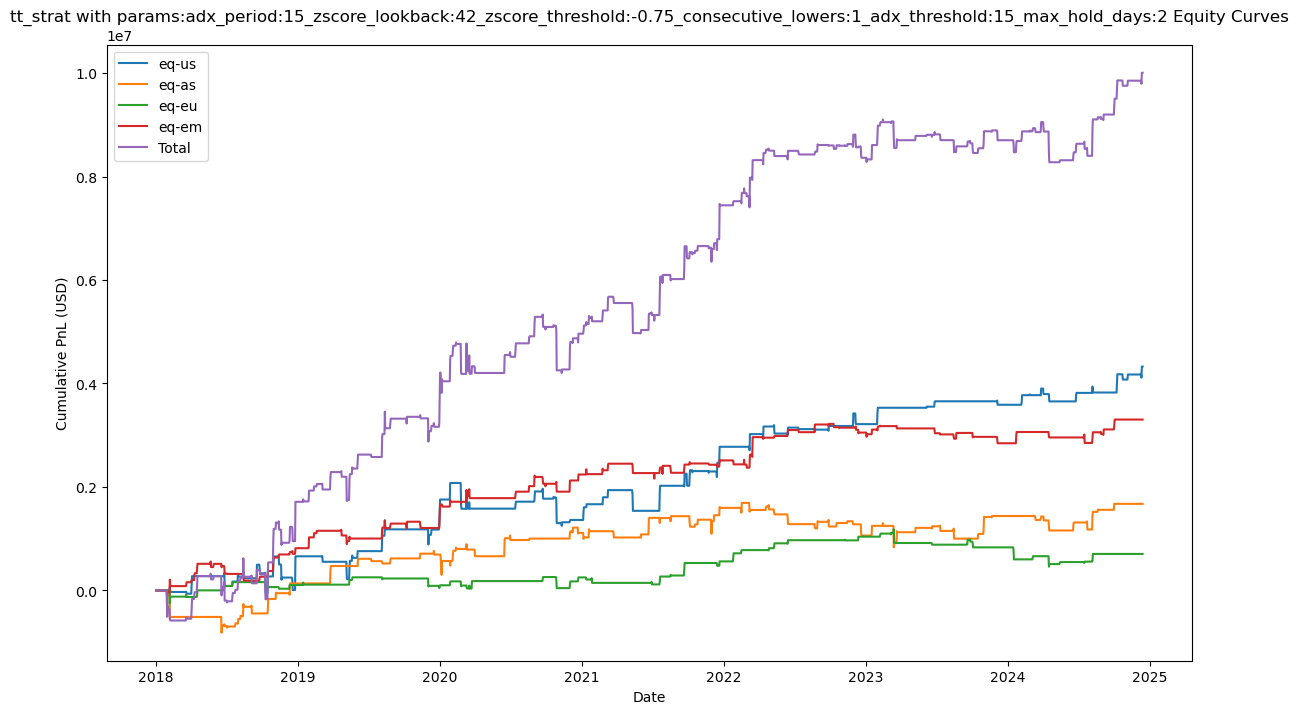

,eq-us,eq-as,eq-eu,eq-em,Total
Date,,,,,
2018-01-02,0.00,0.00,0.00,0.00,0.00
2018-01-03,0.00,0.00,0.00,0.00,0.00
2018-01-04,0.00,0.00,0.00,0.00,0.00
2018-01-05,0.00,0.00,0.00,0.00,0.00
2018-01-08,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...
2024-12-09,"4,173,475","1,672,875","704,793","3,302,304","9,853,447"
2024-12-10,"4,112,635","1,672,875","704,793","3,302,304","9,792,607"
2024-12-11,"4,327,460","1,672,875","704,793","3,302,304","10,007,432"


In [241]:
tt_long.plot_equity(totalsys=True, byac=True, start_date='01012018')

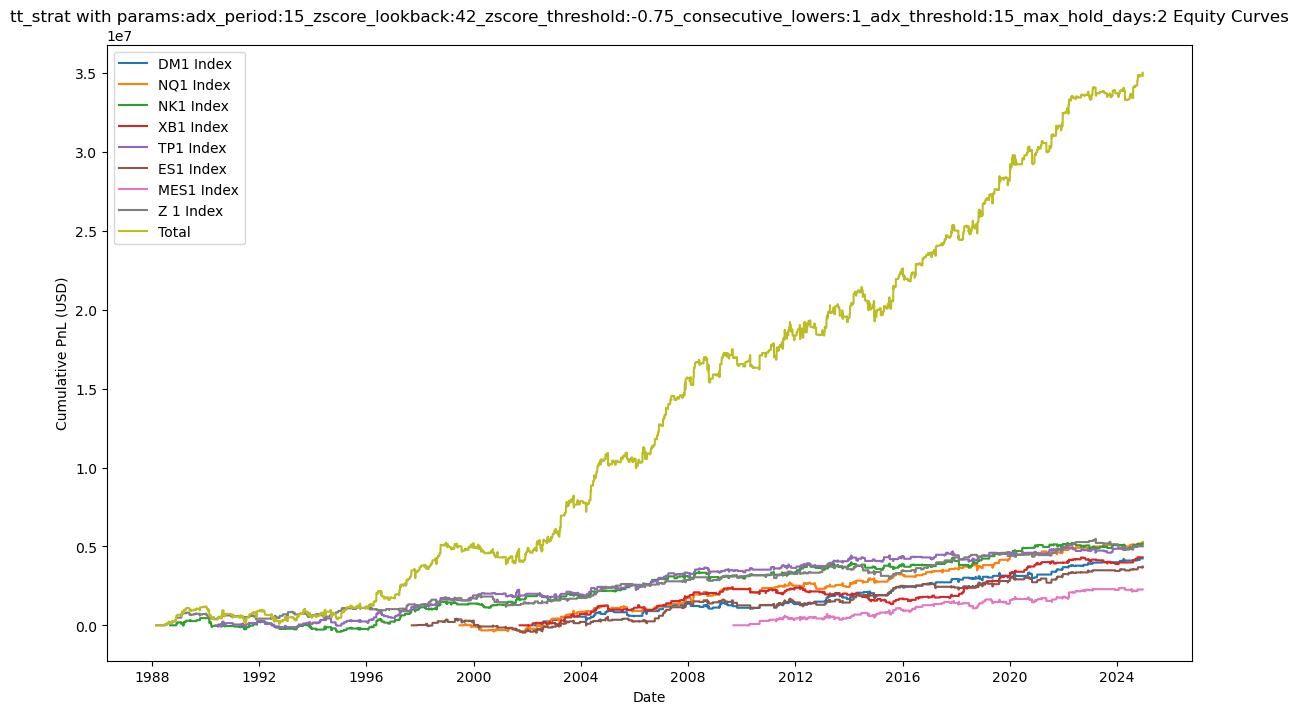

,DM1 Index,NQ1 Index,NK1 Index,XB1 Index,TP1 Index,ES1 Index,MES1 Index,Z 1 Index,Total
Date,,,,,,,,,
1988-02-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
1988-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00
1988-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00
1988-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00
1988-03-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00
...,...,...,...,...,...,...,...,...,...
2024-12-09,"4,239,415","5,180,880","5,157,502","4,310,030","5,019,471","3,679,662","2,268,625","5,009,243","34,864,828"
2024-12-10,"4,239,415","5,155,040","5,157,502","4,310,030","5,019,471","3,644,662","2,268,625","5,009,243","34,803,988"
2024-12-11,"4,239,415","5,288,490","5,157,502","4,310,030","5,019,471","3,726,037","2,268,625","5,009,243","35,018,813"


In [242]:
tt_long.plot_equity(totalsys=True, byassets=True)

In [243]:
tt_long.calculate_statistics(totalsys=True, byassets=True, start_date='01012018').sort_values('Sharpe Ratio (ann.)', ascending=False)

,Total PnL,Average Ann. PnL,Average Ann. Vol,Sharpe Ratio (ann.),Sortino Ratio (ann.),Max drawdown,Average drawdown,Max drawdown Duration,Avg Drawdown Duration,Total Number of Drawdowns,...,Daily Left Tail,Daily Right Tail,Weekly Left Tail,Weekly Right Tail,Monthly Left Tail,Monthly Right Tail,Quarterly Left Tail,Quarterly Right Tail,Yearly Left Tail,Yearly Right Tail
Column,,,,,,,,,,,,,,,,,,,,,
XB1 Index,"2,448,084","344,646","263,257",1.31,0.74,"412,753","138,017",525,64.9,18,...,8.27,-14.4,2.98,-4.19,1.32,4.53,0.75,0.99,0.73,0.42
Total,"10,007,432","1,408,867","1,298,242",1.09,0.61,"1,131,514","285,433",384,43.0,33,...,10.2,-13.1,4.31,-7.78,1.55,1.47,0.73,0.73,0.64,0.68
NQ1 Index,"1,686,815","237,473","318,391",0.75,0.21,"389,020","66,725",224,76.6,14,...,10.6,-20.2,6.77,-7.32,2.13,-3.67,0.80,1.49,0.43,1.63
ES1 Index,"1,333,655","187,755","287,763",0.65,0.23,"403,717","112,988",470,83.9,14,...,15.0,-24.4,9.55,-7.63,3.96,-7.76,1.60,0.93,0.83,1.04
DM1 Index,"1,306,990","184,001","290,009",0.63,0.21,"371,625","120,714",365,64.9,17,...,15.0,-25.8,6.27,-9.57,3.77,-10.5,1.38,0.81,0.94,2.80
NK1 Index,"1,086,628","152,978","310,186",0.49,0.17,"482,777","156,499",687,96.6,14,...,21.5,-33.3,12.4,-10.3,3.49,2.85,1.06,0.65,0.71,0.96
MES1 Index,"854,220","120,259","307,507",0.39,0.15,"407,830","119,917",408,112.8,13,...,29.8,-32.6,12.9,-10.5,4.17,44.5,1.81,1.79,0.55,1.93
Z 1 Index,"704,793","99,222","276,011",0.36,0.09,"724,887","217,383",457,109.3,11,...,24.2,-37.4,17.7,-16.3,5.78,-58.2,1.00,1.03,0.83,1.60
TP1 Index,"586,247","82,533","296,545",0.28,0.09,"404,402","149,549",669,171.4,9,...,35.8,-45.6,15.6,-22.5,3.44,-10.2,0.81,1.23,0.71,0.96


In [239]:
pd.set_option('display.max_rows', 40)

tt_long.strat_monthly_pnl(totalsys=True, byassets=True, start_date='01012010')

,1,2,3,4,5,6,7,8,9,10,11,12,Annual_PnL,Sharpe_Ratio,Annual_Vol,Hit_Rate,Profit_Factor,Worst_Drawdown
Year,,,,,,,,,,,,,,,,,,
2010,"-151,881","276,047","53,404","-253,492","-163,823","2,964",0.00,"7,884","776,497","144,420","-81,788","212,178","822,409",0.69,"1,201,403",0.57,1.56,"-906,146"
2011,"76,840","292,749","-674,532","527,035","58,723","279,639","172,442","145,257","422,558","359,200","-684,586","9,243","984,568",0.56,"1,702,811",0.58,1.23,"-1,155,743"
2012,"261,641","397,042","-232,090","349,658","-574,952","724,080","-385,237","-52,970","2,430","-435,238","-5,152",0.00,"49,212",0.03,"1,490,827",0.52,1.01,"-939,874"
2013,"215,253","804,999","418,053","-55,029","155,240","273,331","-1,568","-566,124","-113,827","12,555","22,310","-99,946","1,065,247",0.72,"1,440,193",0.53,1.30,"-1,135,692"
2014,"929,791","-22,704","647,123","68,355","1,645","115,806","-265,534","-385,972","-45,233","-426,690","203,321","-460,287","359,622",0.20,"1,734,968",0.56,1.08,"-2,181,885"
2015,"162,631","78,775","-416,016","528,025","-123,514","417,047","74,367","947,062","439,144",0.00,"300,247","320,797","2,728,566",1.66,"1,591,431",0.60,2.31,"-728,111"
2016,"-597,664","-13,625","-79,507","350,309","122,537","545,916",0.00,"29,100","321,515","81,465","134,859","84,460","979,365",0.89,"1,065,569",0.63,1.54,"-825,056"
2017,"-221,659","231,851","421,901","78,890","40,394","75,934","291,430","248,792","-154,027","318,621","434,191","-303,705","1,462,614",1.31,"1,082,382",0.58,1.68,"-369,695"
2018,"-360,123","-222,461","35,362","823,464","-1,397","-471,218","341,672","119,527","42,768","882,117","-269,357","791,533","1,711,886",1.01,"1,645,681",0.65,1.49,"-791,011"
